# Comparing Missense Pathogenicity Predictors Against OncoKB Oncogenicity

**Question:** How well do 8/9 missense variant-effect prediction tools (VEST4, REVEL, MutPred, PrimateAI, VARITY_R, VARITY_ER, ESM1b, EVE, AlphaMissense) agree with OncoKB's oncogenicity calls, and where do they fail?

**Data:** Exonic variants annotated with OncoKB oncogenicity (via the OncoKB API) and joined to precomputed tool scores. Each row is one variant carrying its tool scores plus its OncoKB label.

**Label rule:** Positive = Oncogenic or Likely Oncogenic. Negative = Likely Neutral only. Unknown and Inconclusive are excluded, because absence != neutrality.

## 1. Data loading, label distribution, and score coverage

We load the annotated file, restrict to rows OncoKB successfully annotated, apply the label rule, and check how complete the tool scores are within the labeled set.

In [3]:
import pandas as pd
# 1. Load the annotated file
df = pd.read_csv("exonic_toolscores_oncokb_apicall.txt", sep="\t", low_memory=False)
print("Total rows:", len(df))

# 2. Keep only rows OncoKB actually annotated
df = df[df["ANNOTATED"] == True]
print("Annotated rows:", len(df))

# 3. Look at the label distribution
print("\nONCOGENIC distribution:")
print(df["ONCOGENIC"].value_counts(dropna=False))

# 4. Define usable labels
#    positives = Oncogenic / Likely Oncogenic ; negative = Likely Neutral only
positives = ["Oncogenic", "Likely Oncogenic"]
negatives = ["Likely Neutral"]
df_labeled = df[df["ONCOGENIC"].isin(positives + negatives)].copy()
df_labeled["label"] = df_labeled["ONCOGENIC"].isin(positives).astype(int)
print("\nUsable labeled rows:", len(df_labeled))
print(df_labeled["label"].value_counts())   # 1 = oncogenic, 0 = neutral

# 5. Check missingness in the 8 tool-score columns
tool_cols = ["VEST4_score","REVEL_score","MutPred_score","PrimateAI_score",
             "VARITY_R_score","VARITY_ER_score","ESM1b_score","EVE_score","AlphaMissense_score"]
for c in tool_cols:
    df_labeled[c] = pd.to_numeric(df_labeled[c], errors="coerce")   # "." -> NaN
print("\nMissing values per tool (within labeled set):")
print(df_labeled[tool_cols].isna().sum())

Total rows: 169360
Annotated rows: 169360

ONCOGENIC distribution:
ONCOGENIC
Unknown             163558
Likely Oncogenic      5323
Likely Neutral         250
Inconclusive           178
Oncogenic               51
Name: count, dtype: int64

Usable labeled rows: 5624
label
1    5374
0     250
Name: count, dtype: int64

Missing values per tool (within labeled set):
VEST4_score            4420
REVEL_score            4459
MutPred_score          4674
PrimateAI_score        4584
VARITY_R_score         4679
VARITY_ER_score        4679
ESM1b_score            4653
EVE_score              4913
AlphaMissense_score    4559
dtype: int64


- **Labels are scarce and imbalanced:** most variants (163,558) are Unknown. Only 5,624 have usable labels, and they are heavily skewed: 5,374 positive vs 250 negative (about 21 to 1). Likely Neutral is the only clean negative, need other data for the negatives 
- **Tool scores are mostly missing within the labeled set:** every tool is absent for roughly 4,400 to 4,900 of the 5,624 labeled rows (about 80 percent). 

## 2. Why are so many scores missing? Variant type vs coverage

(1) the variant is not a missense change, so a missense tool cannot score it, or (2) the tool does not cover that gene. Separate these by breaking missingness down by variant type, using VEST4 as a representative tool.

In [4]:
# What types of changes are in the data?
print(df["ExonicFunc.refGeneWithVer"].value_counts())

# For each change type, what fraction is covered by each
tool_cols = ["VEST4_score","REVEL_score","MutPred_score","PrimateAI_score",
             "VARITY_R_score","VARITY_ER_score","ESM1b_score","EVE_score","AlphaMissense_score"]

# True = score is blank for that tool
miss = pd.DataFrame({c: pd.to_numeric(df[c], errors="coerce").isna() for c in tool_cols})
miss["ExonicFunc"] = df["ExonicFunc.refGeneWithVer"].values

coverage = miss.groupby("ExonicFunc")[tool_cols].mean().round(3)
print(coverage)

ExonicFunc.refGeneWithVer
nonsynonymous SNV          102603
synonymous SNV              53349
frameshift deletion          4192
stopgain                     3884
frameshift insertion         2245
nonframeshift deletion       1723
nonframeshift insertion       941
startloss                     316
stoploss                      107
Name: count, dtype: int64
                         VEST4_score  REVEL_score  MutPred_score  \
ExonicFunc                                                         
frameshift deletion            1.000        1.000          1.000   
frameshift insertion           1.000        1.000          1.000   
nonframeshift deletion         1.000        1.000          1.000   
nonframeshift insertion        1.000        1.000          1.000   
nonsynonymous SNV              0.008        0.029          0.150   
startloss                      0.114        0.130          0.190   
stopgain                       0.160        0.994          0.995   
stoploss                      

### Tool coverage differs

On non-missense variants (indels, synonymous), all 8 tools are 100% blank, confirming the whole class only handles missense.

On missense variants, coverage varies. Most tools score 93 to 99 percent (VEST4 99.2, AlphaMissense 98.6, REVEL 97.1, PrimateAI 96.5, ESM1b 94.2, VARITY 93.2). Two have real gaps: MutPred misses 15 percent and EVE misses 44 percent, reflecting EVE's limited gene coverage. Because EVE is missing so often, we keep variants it didn't score and simply let EVE abstain, rather than discarding those variants and wasting the other tools' scores.

In [5]:
missense = df[df["ExonicFunc.refGeneWithVer"] == "nonsynonymous SNV"].copy()
lab = missense[missense["ONCOGENIC"].isin(["Oncogenic","Likely Oncogenic","Likely Neutral"])].copy()
lab["label"] = lab["ONCOGENIC"].isin(["Oncogenic","Likely Oncogenic"]).astype(int)
for c in tool_cols:
    lab[c] = pd.to_numeric(lab[c], errors="coerce")
print("Labeled missense rows:", len(lab))
print(lab["label"].value_counts())   # 1 = oncogenic, 0 = neutral

Labeled missense rows: 1043
label
1    824
0    219
Name: count, dtype: int64


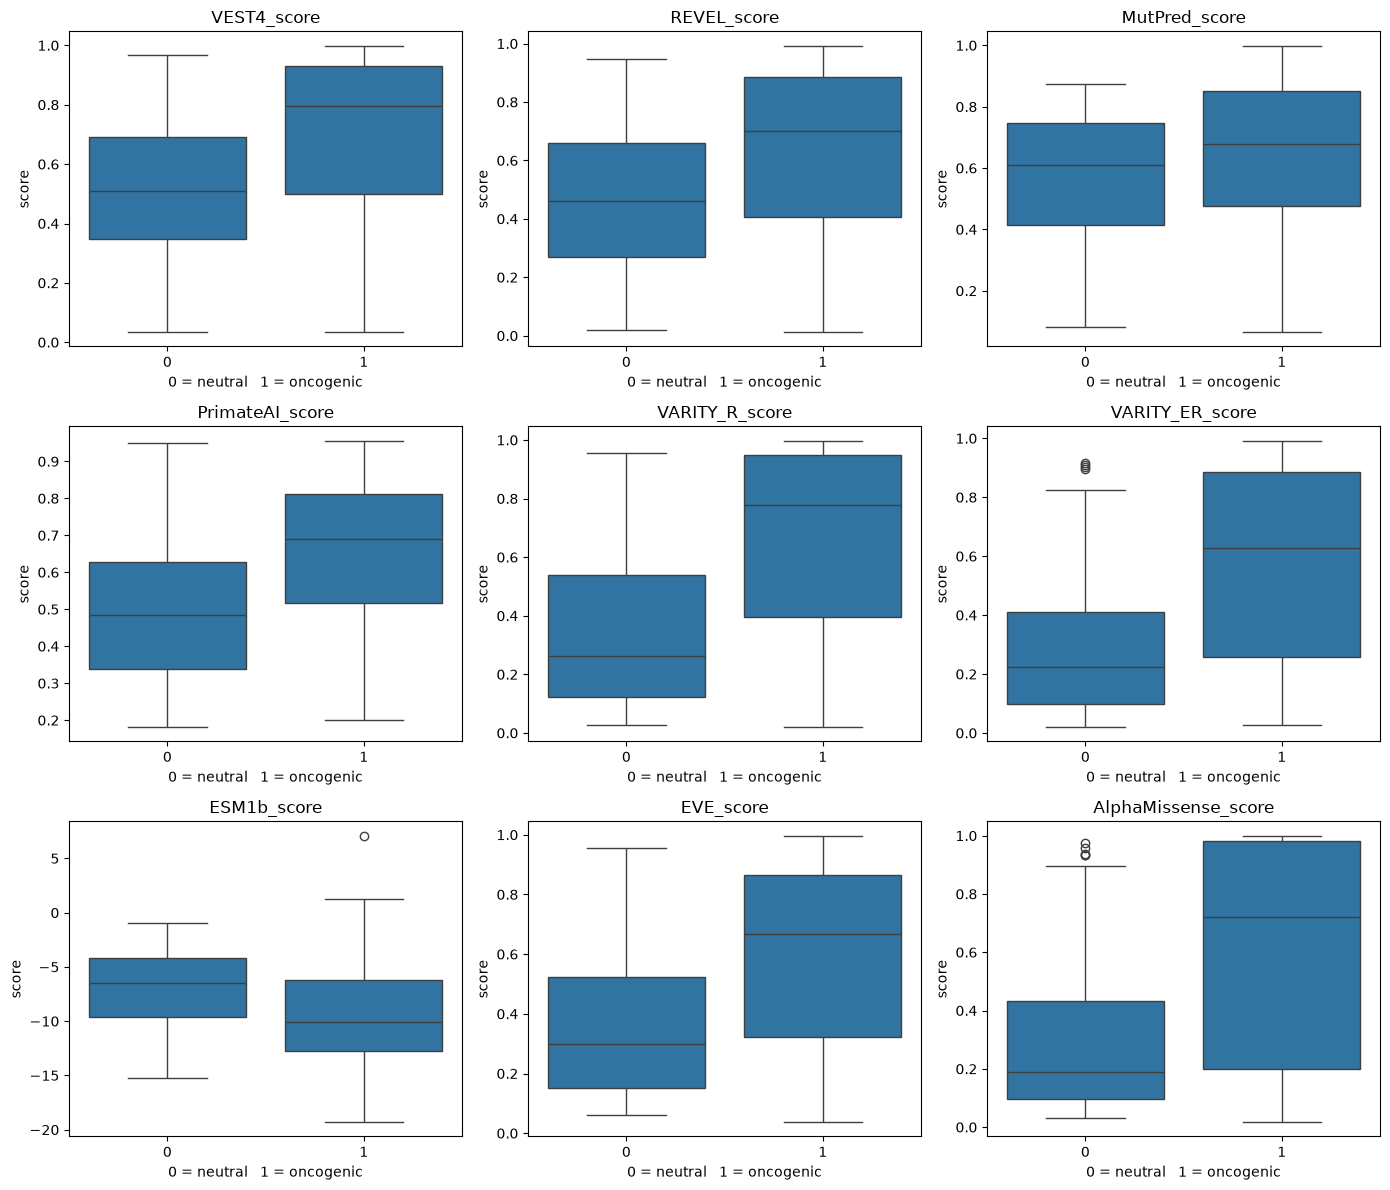

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
for ax, c in zip(axes.flat, tool_cols):
    sns.boxplot(data=lab, x="label", y=c, ax=ax)
    ax.set_title(c)
    ax.set_xlabel("0 = neutral   1 = oncogenic")
    ax.set_ylabel("score")
plt.tight_layout()
plt.show()

### Reading the score distributions

Each tool assigns every variant a score, where a higher score means a more damaging prediction with ESM1b as an excpetion. Each panel splits the 1,043 labeled missense variants into two groups by their OncoKB label, neutral (0) and oncogenic (1), and shows how that tool's scores are distributed in each group. The line inside each box is the group's median score, and the box covers the middle half of the scores.

A tool separates the two classes well when the oncogenic box sits clearly higher than the neutral box with little overlap. A large vertical gap means the tool's scores track oncogenicity; heavily overlapping boxes mean the tool gives similar scores to both groups and distinguishes them poorly.

### What the distributions show

Across the 1,043 labeled missense variants (824 oncogenic, 219 neutral), most tools assign higher scores to oncogenic variants than to neutral ones

- **Strongest separation:** AlphaMissense (median 0.19 neutral vs 0.72 oncogenic), VARITY_R (0.26 vs 0.78), and VARITY_ER (0.22 vs 0.62). The two groups are clearly apart.
- **Moderate separation:** VEST4 (0.51 vs 0.80), REVEL (0.46 vs 0.70), PrimateAI (0.49 vs 0.69), and EVE (0.30 vs 0.67). With more overlap.
- **Weakest separation:** MutPred (0.61 vs 0.67), e two distributions overlap almost entirely and barely distinguish the classes.

ESM1b uses the opposite convention, where more negative scores indicate more damaging predictions, so its oncogenic group falls below its neutral group. It separates the classes in the reverse direction and must be inverted before separation metrics are computed.

In [7]:
from sklearn.metrics import roc_auc_score, average_precision_score

results = []
for c in tool_cols:
    s = lab[[c, "label"]].dropna()          # only rows where THIS tool has a score
    scores = s[c].values
    if c == "ESM1b_score":
        scores = -scores                     # flip: ESM1b is inverted
    y = s["label"].values
    results.append({
        "tool": c,
        "n": len(s),
        "n_pos": int(y.sum()),
        "n_neg": int((y == 0).sum()),
        "AUROC": round(roc_auc_score(y, scores), 3),
        "AUPRC": round(average_precision_score(y, scores), 3),
    })

res = pd.DataFrame(results).sort_values("AUROC", ascending=False).reset_index(drop=True)
print(res)

                  tool     n  n_pos  n_neg  AUROC  AUPRC
0       VARITY_R_score   813    714     99  0.764  0.960
1  AlphaMissense_score  1032    814    218  0.738  0.924
2      VARITY_ER_score   813    714     99  0.737  0.955
3      PrimateAI_score  1009    791    218  0.729  0.905
4            EVE_score   691    619     72  0.724  0.958
5          VEST4_score  1032    814    218  0.712  0.911
6          ESM1b_score   835    736     99  0.695  0.944
7          REVEL_score  1031    813    218  0.687  0.901
8        MutPred_score   826    707    119  0.607  0.914


### Per-tool separation (AUROC / AUPRC)

Each tool was scored on the labeled missense variants it covers. AUROC is the probability the tool ranks a random oncogenic variant above a random neutral one (0.5 = chance, 1.0 = perfect).

No tool performs strongly: AUROC ranges from 0.61 (MutPred) to 0.76 (VARITY_R), with most clustered near 0.70 to 0.74. VARITY_R, AlphaMissense, and VARITY_ER rank highest; MutPred is clearly weakest. AUPRC is high for all tools (0.90 to 0.96) but is inflated because positives form 79 percent of the set, so AUROC is the primary metric.

These per-tool scores use different variant subsets (n_neg ranges from 72 to 218) because tools cover different variants, so the ranking is not yet a fair comparison. Re-evualting all tools on the common set of variants they all cover.

In [8]:
# Keep only variants where ALL tools have a score
complete = lab.dropna(subset=tool_cols).copy()
print("Complete-case rows:", len(complete))
print(complete["label"].value_counts())   # how many oncogenic vs neutral survive

# Re-score every tool on this identical set
y = complete["label"].values
results_cc = []
for c in tool_cols:
    scores = complete[c].values
    if c == "ESM1b_score":
        scores = -scores
    results_cc.append({
        "tool": c,
        "AUROC": round(roc_auc_score(y, scores), 3),
        "AUPRC": round(average_precision_score(y, scores), 3),
    })

res_cc = pd.DataFrame(results_cc).sort_values("AUROC", ascending=False).reset_index(drop=True)
print(f"\nComplete-case ranking (all tools on the same {len(complete)} variants):")
print(res_cc)

Complete-case rows: 576
label
1    541
0     35
Name: count, dtype: int64

Complete-case ranking (all tools on the same 576 variants):
                  tool  AUROC  AUPRC
0       VARITY_R_score  0.752  0.979
1      VARITY_ER_score  0.748  0.979
2  AlphaMissense_score  0.733  0.979
3            EVE_score  0.719  0.974
4          REVEL_score  0.706  0.974
5          ESM1b_score  0.676  0.968
6          VEST4_score  0.675  0.972
7      PrimateAI_score  0.651  0.967
8        MutPred_score  0.643  0.968


### Fair comparison: all tools on the same variants

Restricting to variants scored by every tool (complete cases) gives a fair ranking on an identical set, but shrinks the data to 576 variants with only 35 negatives (EVE's coverage is the binding constraint). AUROC values are therefore directional; AUPRC is uninformative at 94 percent positives and is not reported.

VARITY_R, VARITY_ER, AlphaMissense, and EVE remain the top performers under both the per-tool and complete-case rankings, so their standing is robust. PrimateAI drops sharply (0.729 to 0.651) once evaluated on the common set, showing its earlier rank was inflated by the subset it happened to cover. MutPred remains weakest. Overall, no tool exceeds AUROC 0.76, indicating only moderate agreement with OncoKB oncogenicity on this curated set.

## Tool agreement

**Purpose.** . This section measures agreement between the tools themselves. That matters for the combination goal: combining tools only adds value when they carry complementary information. Stacking tools that already agree adds little, while pairing tools that disagree in useful ways can improve coverage.

**Method.** Agreement is measured as the Spearman correlation between each pair of tool scores. First, this uses all missense variants (~100k), not just the labeled set, because the analysis compares tools to each other and does not need the OncoKB label. Using all available variants gives a stable estimate and avoids dependence on the small labeled negative class. Second, Spearman (rank correlation) is used rather than Pearson because the tools are on very different scales (most run 0 to 1, ESM1b runs about -20 to +5) and the question is whether tools rank variants in the same order, not whether their raw numbers match. ESM1b is inverted first so all tools share the same direction.

**What it shows.** A correlation near 1 means two tools rank variants are largely redundant; a lower value means they carry more independent signal. Highly correlated groups contribute overlapping information and tools that agree less with the rest are the more valuable additions to a combination. 

**Takeaway.** The combination strategy should favor complementary tools over redundant ones. Tool agreement identifies which tools are interchangeable and which add distinct signal, informing which subset is worth combining.

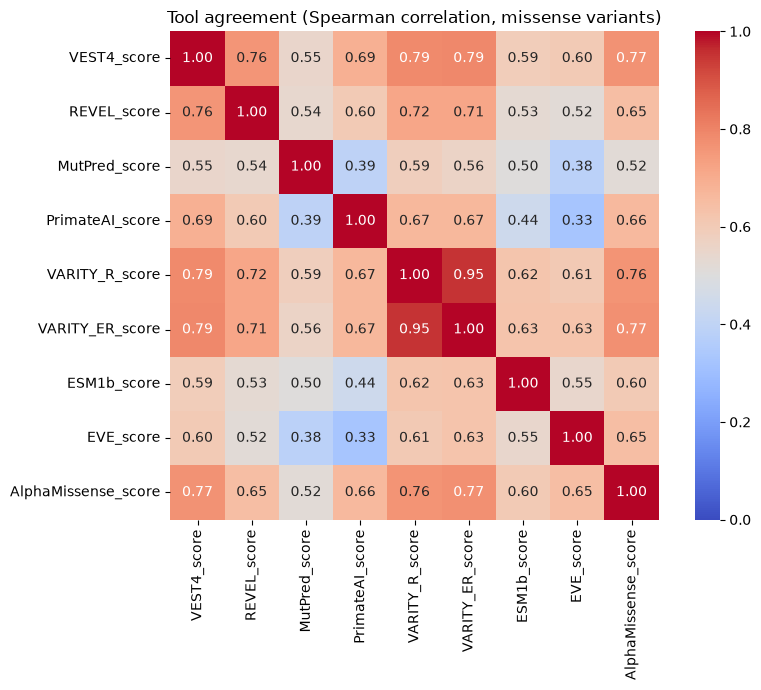

In [ ]:
# all missense variants; make scores numeric
scores_df = missense[tool_cols].apply(pd.to_numeric, errors="coerce").copy()
scores_df["ESM1b_score"] = -scores_df["ESM1b_score"]   # flip so higher = more damaging everywhere

corr = scores_df.corr(method="spearman")

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1, square=True)
plt.title("Tool agreement (Spearman correlation, missense variants)")
plt.tight_layout()
plt.show()

**What it shows.** Agreement is moderate overall (most pairs 0.5 to 0.8). VARITY_R and VARITY_ER are near-identical (0.95) and redundant. A cluster of supervised tools (VEST4, REVEL, VARITY, AlphaMissense) agree at roughly 0.7 to 0.8 and carry overlapping signal, though this may partly reflect shared training data rather than independent evidence. EVE, PrimateAI, ESM1b, and MutPred are more independent, with the lowest agreements in the matrix among them (EVE-PrimateAI 0.33, MutPred-EVE 0.38).

In [10]:
from sklearn.metrics import roc_curve

cc = complete.copy()          # 576 complete-case variants (all tools present)
y = cc["label"].values

# 1. Fair cutoff per tool (Youden's J), then a binary "flagged oncogenic"
calls = pd.DataFrame(index=cc.index)
for c in tool_cols:
    s = cc[c].values.astype(float)
    if c == "ESM1b_score":
        s = -s
    fpr, tpr, thr = roc_curve(y, s)
    t = thr[(tpr - fpr).argmax()]      # threshold that best separates
    calls[c] = (s >= t).astype(int)

# 2. For each variant, how many of the 9 tools flagged it
calls["n_flag"] = calls[tool_cols].sum(axis=1)
calls["label"] = y

# 3. Among true oncogenic variants: how many tools caught each?
onco = calls[calls["label"] == 1]
print("Oncogenic variants by number of tools that caught them:")
print(onco["n_flag"].value_counts().sort_index())

# 4. Complementarity: best single tool vs combining
recalls = {c: calls.loc[calls.label == 1, c].mean() for c in tool_cols}
best = max(recalls, key=recalls.get)
print(f"\nBest single tool recall: {best} = {recalls[best]:.3f}")
print(f"Union recall (any tool flags): {(onco['n_flag'] >= 1).mean():.3f}")

# 5. The cost side (limited by 35 negatives): neutrals wrongly flagged by >=1 tool
neut = calls[calls["label"] == 0]
print(f"Neutrals flagged by at least one tool: {(neut['n_flag'] >= 1).mean():.3f}")

Oncogenic variants by number of tools that caught them:
n_flag
0     55
1     35
2     42
3     30
4     37
5     37
6     28
7     63
8    106
9    108
Name: count, dtype: int64

Best single tool recall: EVE_score = 0.769
Union recall (any tool flags): 0.898
Neutrals flagged by at least one tool: 0.771
